# Physically Informed Neural Network for the Acoustic Wave Equation
We aim at building a function $p(x, y, x_0, y_0, t)$ which gives the value of a pressure field evolving through time, subject to an external pressure source, where the pressure wave propagates according to the acoustic wave equation. This function shouldgive the value of the pressure field at a specific spatiotemporal point, when the wave is excited by an external source centered in $(x_0, y_0)$. The acoustic wave equation is given by $$\frac{\partial^2 p}{\partial t^2} = c^2\nabla^2 p + s,$$ where $s$ is the external forcing term. The function $c$ is continuous in space but fixed in time (in the current case, it is a constant function $c=5$ everywhere, but it can be generalized to non-constant functions). 

The function can be approximated by a Neural Network, trained to optimize minimize, for any input $(x, y, x_0, y_0, t)$, the residual $$|\frac{\partial^2 p_{x, y, t}}{\partial t^2} - 5^2\nabla^2 p_{x, y, t} - s_{x, y, x_0, y_0, t}|$$, where the subcript $(x, y, t)$ denotes the evaluation of a function at those coordinates in space and time.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchsummary import summary
import io
import imageio
from IPython.display import display, Image, clear_output
import ipywidgets as widgets
from torch.nn.parallel import DataParallel
from scipy.ndimage import zoom
from scipy.interpolate import RegularGridInterpolator
device = "cuda"
n_gpus = torch.cuda.device_count()
print(f"GPUs disponibles : {n_gpus}")

GPUs disponibles : 3


We define the external source function. It is a Gaussian field centered in $(x_0, y_0)$, multiplied by a Ricker wavelet, whose peak is at $t=1$.

In [2]:
def source(x, y, t, cx=0, cy=0, sigma=1., amplitude_g=1e2, f=2.0, amplitude_r=1.0, t0=1):
    gaussian = amplitude_g * torch.exp(-((x - cx)**2/(2*sigma**2)+(y - cy)**2/(2*sigma**2)))
    pi2f2tau2 = (torch.pi * f)**2 * (t - t0)**2
    ricker = amplitude_r * (1.0 - 2.0 * pi2f2tau2) * torch.exp(-pi2f2tau2)
    return gaussian * ricker

n_t = 1000
plt.figure(figsize=(12, 5))
plt.plot(torch.arange(0, 5, 5/n_t), source(torch.zeros(n_t), torch.zeros(n_t), torch.arange(0, 5, 5/n_t), 0, 0))
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("External forcing term measured in (0, 0)")
plt.grid()
plt.show()

We will work in a wave propagation speed field where the speed increases with depth, mimicking an augmentation in density:

In [3]:
c_map = np.load("Density_Test.npy")[8].reshape((51, 51))
c_map = zoom(c_map, 1024/51)

coords = np.linspace(-10, 10, 1024)
interp = RegularGridInterpolator((coords, coords), c_map, method='nearest', bounds_error=False, fill_value=None)

def c(x, y, t=0):
    if isinstance(x, torch.Tensor): x = x.cpu().detach().numpy()
    if isinstance(y, torch.Tensor): y = y.cpu().detach().numpy()
    return torch.tensor(interp(np.stack([y.ravel(), x.ravel()], axis=-1)).reshape(x.shape), dtype=torch.float32).to(device)
    
def c_constant(x, y, t=0):
    if type(y) == np.ndarray:
        y = torch.tensor(y)
    if type(x) == np.ndarray:
        x = torch.tensor(x)
    return 10*torch.ones_like(y)

x = torch.linspace(-10, 10, 300)
y = torch.linspace(-10, 10, 300)
X, Y = torch.meshgrid(x, y, indexing='xy')
Z = c(X, Y)
plt.imshow(Z.cpu().numpy(), extent=[-50, 50, -50, 50], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='c(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

We construct a Finite Difference solver which will serve as reference.

In [4]:
def run_fd_reference(c0: float = 1.0, t_max: float = 5.0, n_t: int = 250, L: float = 40.0, dx: float = 1.0, t0=1, cx=0, cy=0):
    dt = t_max / n_t
    nx = int(2 * L / dx) + 1
    x1d = np.linspace(-L, L, nx)
    X, Y = np.meshgrid(x1d, x1d, indexing="ij")

    Z = c(X, Y).cpu().numpy()

    cfl = np.max(Z).item() * dt / dx
    assert cfl < 1 / np.sqrt(2), f"CFL = {cfl:.3f} unstable, reduce dt or increase dx"
    r2 = (Z * dt / dx) ** 2

    p_prev = np.zeros((nx, nx))
    p_curr = np.zeros((nx, nx))

    def idx(v): return int(round((v + L) / dx))
    rec_pts = {
        "(-5,5)":   (idx(-5), idx(5)),
        "(0.1,0.1)":    (idx(0.1),  idx(.1)),
        "(0.5,-2)": (idx(0.5),  idx(-2)),
    }
    traces = {k: np.zeros(n_t) for k in rec_pts}
    t_arr  = np.linspace(0, t_max, n_t)

    for it, t in enumerate(t_arr):
        lap = (p_curr[2:,  1:-1] + p_curr[:-2, 1:-1] +
               p_curr[1:-1, 2:] + p_curr[1:-1, :-2] -
               4.0 * p_curr[1:-1, 1:-1])

        src = source(torch.tensor(X), torch.tensor(Y), torch.tensor(t),
                     t0=t0, cx=cx, cy=cy).numpy()[1:-1, 1:-1]

        p_next = np.zeros_like(p_curr)
        p_next[1:-1, 1:-1] = (
            2.0 * p_curr[1:-1, 1:-1]
            - p_prev[1:-1, 1:-1]
            + r2[1:-1, 1:-1] * lap
            + dt**2 * src
        )

        for k, (ix, iy) in rec_pts.items():
            traces[k][it] = p_next[ix, iy]

        p_prev, p_curr = p_curr, p_next

    return t_arr, traces

We design a function to check specific seismograms produced by querying the model:

In [5]:
gif_frames = []
GIF_PATH   = "training_progress.gif"
_gif_display_handle = None

receiver_labels=["(-5,5)", "(0.1,0.1)", "(0.5,-2)"]

def check_seismograms(c_val: float = 5.0, t_max: float = 5.0, n_t: int = 500, t_0=1, cx=0, cy=0):
    model = torch.load("model.pt", weights_only=False)
    global gif_frames, _gif_display_handle
    x  = torch.ones(n_t, 1, device=device)
    y  = torch.ones(n_t, 1, device=device)
    t  = torch.linspace(0, t_max, n_t, device=device).unsqueeze(1)
    t_np     = t.squeeze().cpu().numpy()
    #fig, axes = plt.subplots(len(t_0), 3, figsize=(20, 6*len(t_0)))
    plt.figure(figsize=(20, 10))
    for i in range(len(t_0)):
        t_fd, fd_seis = run_fd_reference(c_val, t_max, n_t, t0=t_0[i], cx=cx, cy=cy)
        t0 = torch.ones_like(t, device=device) * t_0[i]
        with torch.no_grad():
            p_neg1 = model(-5*x, 5*y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            p_zero = model(0.1*x, 0.1*y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            p_pos1 = model(0.5*x, -2*y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            pinn_seis = {'(-5,5)': p_neg1, '(0.1,0.1)': p_zero, '(0.5,-2)': p_pos1}
        for label in receiver_labels:
            plt.plot(t_np, pinn_seis[label], label=f'PINN {label}',   linewidth=1.5)
            plt.plot(t_fd, fd_seis[label],   label=f'FD ref {label}', linewidth=1.5, linestyle='--')
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.xlim([0, t_max])
        plt.ylim([5*np.min(fd_seis[label]), 5*np.max(fd_seis[label])])
        plt.legend(loc='upper right')
        plt.grid(True)
    plt.title(
        f"Seismograms - src=({cx},{cy})  "
        f"Iteration {(len(gif_frames)+1)}  (PINN vs FD reference)",
        fontsize=13,
    )
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=80)
    buf.seek(0)
    gif_frames.append(buf.read())
    plt.close()
    if len(gif_frames) >= 1:
        import imageio.v2 as iio2
        imgs = [iio2.imread(io.BytesIO(f)) for f in gif_frames]
        
        with iio2.get_writer(GIF_PATH, mode="I", loop=0) as writer:
            for i, img in enumerate(imgs):
                repeats = 4 if i == len(imgs) - 1 else 1
                for _ in range(repeats):
                    writer.append_data(img, {"duration": 100})
    gif_bytes = open(GIF_PATH, "rb").read()
    if _gif_display_handle is None:
        _gif_display_handle = display(
            Image(data=gif_bytes, format="gif"),
            display_id="seismo_gif"
        )
    else:
        _gif_display_handle.update(Image(data=gif_bytes, format="gif"))

We train the PINN. To do so, we sample random points $x, y, t$, alongside with random values $c$, and we compute the loss of the output produced by the PINN. $x, y$ are sampled in $[-1, 1]$, $t$ is sampled in $[0, 10]$ and $c$ is sampled in $[0.02, 2.02]$. Since we want to overfit the loss function, we purposely chose a small learning rate. Also, it is well-known that PINN's require a really long training for convergence.

  0%|          | 0/100000 [00:00<?, ?it/s]

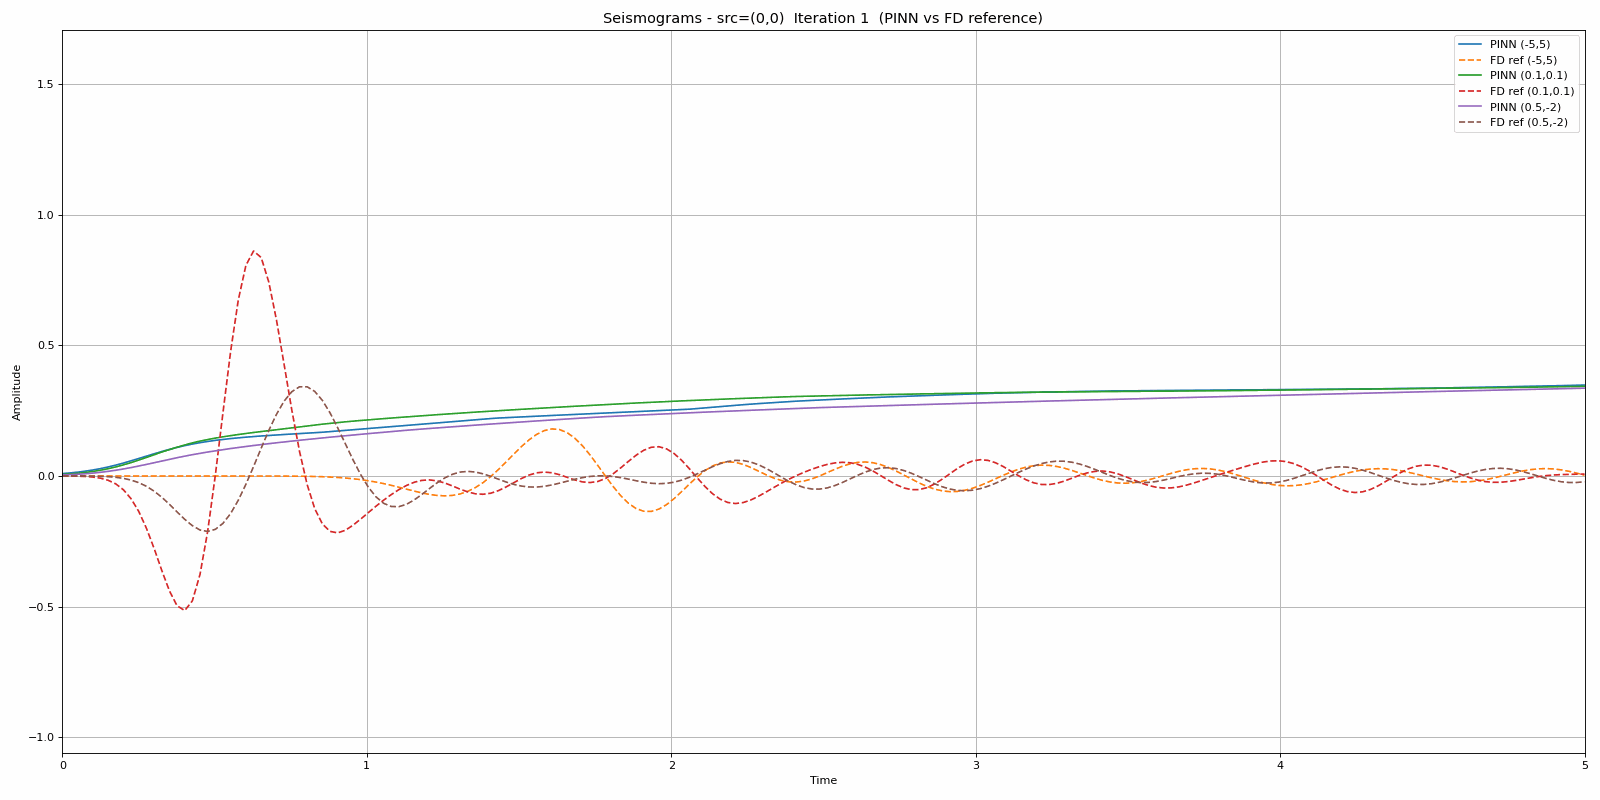

In [ ]:
TRAINING = True
_gif_display_handle = None
gif_frames = []

def g(t, t0, alpha=5.0):
    return 0.5 * (torch.tanh(alpha * (t + t0)) + 1)

class SinLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.p = nn.Parameter(torch.tensor([1.0]))
        self.q = 1#nn.Parameter(torch.tensor([1.0]))
    def forward(self, x):
        return self.q*torch.sin(self.p*x)

class PINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        self.input_layer = nn.Sequential(nn.Linear(5, width), nn.Mish())
        self.hidden_layers = nn.ModuleList([
            nn.Sequential(nn.Linear(width, width), nn.ReLU())
            for _ in range(depth - 1)
        ] + [SinLayer()])
        self.output_layer = nn.Linear(width, 1)

    def forward(self, x, y, t, x0, y0, t0):
        inp = torch.cat([x, y, t, x0, y0], dim=-1)#torch.cat([x, y, t, x0, y0, t0], dim=-1)
        h = self.input_layer(inp)
        for layer in self.hidden_layers:
            h = layer(h) + h
        p = self.output_layer(h)
        return p * g(t - t0, t0 / 2)

def loss_fn(model, x, y, t, x0, y0, t0):
    pred = model(x, y, t, x0, y0, t0)
    s_xyt = source(x, y, t, cx=x0, cy=y0, t0=t0)
    ones = torch.ones_like(pred)
    dp_dx, dp_dy, dp_dt = torch.autograd.grad(pred, [x, y, t], grad_outputs=ones, create_graph=True)
    dp_dxx = torch.autograd.grad(dp_dx, x, grad_outputs=ones, create_graph=True)[0]
    dp_dyy = torch.autograd.grad(dp_dy, y, grad_outputs=ones, create_graph=True)[0]
    dp_dtt = torch.autograd.grad(dp_dt, t, grad_outputs=ones, create_graph=True)[0]
    pde_res = dp_dtt - (c(x, y, t) ** 2) * (dp_dxx + dp_dyy) - s_xyt
    return (pde_res ** 2).mean()

if TRAINING:
    min_loss = 2.5e-2
    model = PINN(16, 8).to(device)
    
    if n_gpus > 1:
        model = DataParallel(model)
    
    V             = 1.0
    N_POINTS      = int(1e5)
    SPATIAL_RANGE_X  = 50.0
    SPATIAL_RANGE_Y  = 50.0
    SPATIAL_RANGE_X0 = 10.0
    SPATIAL_RANGE_Y0 = 10.0
    T0_MAX        = 1.0
    T_MAX         = 5.0
    N_STEPS       = 100_000
    LR            = 1e-2
    CKPT_EVERY    = 300
    WAVE_SPEED    = 10.0
    FRAC_CAUSAL   = 0.9
    T_WINDOW      = T_MAX - T0_MAX
    
    n_causal  = int(N_POINTS * FRAC_CAUSAL)
    n_acausal = N_POINTS - n_causal
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR, total_steps=N_STEPS, div_factor=1e1, final_div_factor=1e4
    )
    
    def sample_batch():
        x  = (torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_X
        y  = (torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_Y
        x0 = torch.zeros(N_POINTS, 1, device=device)#(torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_X0
        y0 = torch.zeros(N_POINTS, 1, device=device)#(torch.rand(N_POINTS, 1, device=device) - 0.5) * 2 * SPATIAL_RANGE_Y0
        t0 = torch.ones(N_POINTS, 1, device=device)*0.5 #torch.rand(N_POINTS, 1, device=device) * T0_MAX + 1.0
    
        dist     = torch.sqrt((x - x0) ** 2 + (y - y0) ** 2)
        t_arrive = t0 + dist / WAVE_SPEED
    
        t_causal  = t_arrive[:n_causal] + torch.rand(n_causal, 1, device=device) * T_WINDOW
        t_causal  = torch.clamp(t_causal, 0.0, T_MAX)
        t_acausal = torch.rand(n_acausal, 1, device=device) * T_MAX
        t = torch.cat([t_causal, t_acausal])
        return x, y, t, x0, y0, t0
    
    losses = []
    
    for step in (pbar := tqdm(range(N_STEPS))):
        x, y, t, x0, y0, t0 = sample_batch()
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)
        t = t.requires_grad_(True)
        optimizer.zero_grad(set_to_none=True)
        loss_pde = loss_fn(model, x, y, t, x0, y0, t0)
        loss_pde.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss_pde.item())
        pbar.set_description(f"loss={np.mean(losses[-20:]):.3e}  lr={scheduler.get_last_lr()[0]:.3e}")
        if loss_pde.item() < min_loss:
            min_loss = loss_pde.item()
            torch.save(model, "model.pt")
            check_seismograms(n_t=200, t_0=[.5])
else:
    model = torch.load("model.pt", weights_only=False)
    check_seismograms(model, n_t=200, t_0=[.5])

In [ ]:
# plt.plot(losses)

In [ ]:
def run_fd_reference_with_fields(t_max: float = 5.0, n_t: int = 250,
                                  L: float = 50.0, dx: float = 1.0, t0=1, cx=0, cy=0,
                                  snapshot_every: int = 10):
    dt = t_max / n_t
    nx = int(2 * L / dx) + 1
    x1d = np.linspace(-L, L, nx)
    X, Y = np.meshgrid(x1d, x1d, indexing="ij")
    Z = c(X, Y).cpu().numpy()
    cfl = np.max(Z).item() * dt / dx
    assert cfl < 1 / np.sqrt(2), f"CFL = {cfl:.3f} unstable"

    r2 = (Z * dt / dx) ** 2
    p_prev = np.zeros((nx, nx))
    p_curr = np.zeros((nx, nx))
    t_arr  = np.linspace(0, t_max, n_t)

    snapshots = []
    for it, t in enumerate(t_arr):
        lap = (p_curr[2:,  1:-1] + p_curr[:-2, 1:-1] +
               p_curr[1:-1, 2:] + p_curr[1:-1, :-2] -
               4.0 * p_curr[1:-1, 1:-1])
        src = source(torch.tensor(X), torch.tensor(Y), torch.tensor(t),
                     t0=t0, cx=cx, cy=cy).numpy()[1:-1, 1:-1]
        p_next = np.zeros_like(p_curr)
        p_next[1:-1, 1:-1] = (
            2.0 * p_curr[1:-1, 1:-1]
            - p_prev[1:-1, 1:-1]
            + r2[1:-1, 1:-1] * lap
            + dt**2 * src
        )
        if it % snapshot_every == 0:
            snapshots.append((t, p_next.copy()))
        p_prev, p_curr = p_curr, p_next

    return t_arr, snapshots, x1d

FIELD_GIF_PATH   = "field_propagation.gif"

def check_wave_field(model, t_max: float = 5.0,
                     n_t: int = 250, t_0=1, cx=0, cy=0,
                     L: float = 50.0, dx: float = 1.0,
                     snapshot_every: int = 10):
    field_gif_frames = []

    t0_val = t_0[0] if isinstance(t_0, (list, np.ndarray)) else t_0
    _, snapshots, x1d = run_fd_reference_with_fields(
        t_max, n_t, L=L, dx=dx,
        t0=t0_val, cx=cx, cy=cy,
        snapshot_every=snapshot_every,
    )
    nx = len(x1d)

    X2d, Y2d = np.meshgrid(x1d, x1d, indexing="ij")
    x_flat    = torch.tensor(X2d.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
    y_flat    = torch.tensor(Y2d.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
    t0_tensor = torch.full_like(x_flat, t0_val)
    cx_tensor = torch.ones_like(x_flat) * cx
    cy_tensor = torch.ones_like(x_flat) * cy

    pinn_fields = []
    with torch.no_grad():
        for snap_t, _ in snapshots:
            t_tensor = torch.full_like(x_flat, snap_t)
            pred = model(x_flat, y_flat, t_tensor,
                         cx_tensor, cy_tensor, t0_tensor)
            pinn_fields.append(pred.squeeze().cpu().numpy().reshape(nx, nx))

    all_fd   = np.stack([f for _, f in snapshots])
    all_pinn = np.stack(pinn_fields)
    vmax     = np.abs(all_fd).max()#max(np.abs(all_fd).max(), np.abs(all_pinn).max()) * 0.8
    vmax     = vmax if vmax > 0 else 1.0
    extent   = [-L, L, -L, L]
    iter_num = len(field_gif_frames) + 1 
    new_frames = []
    for i in tqdm(range(len(snapshots))):
        (snap_t, fd_field), pinn_field = snapshots[i], pinn_fields[i]
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
        fig.suptitle(
            f"Wave-field  |  src=({cx},{cy})  t0={t0_val}  "
            f"t={snap_t:.2f}   Iter {iter_num}",
            fontsize=13,
        )
        for ax, field, title in zip(
            axes,
            [fd_field,        pinn_field],
            ["FD reference",  "PINN prediction"],
        ):
            im = ax.imshow(
                field.T,
                origin="lower", extent=extent,
                cmap="seismic", vmin=-vmax, vmax=vmax,
                aspect="equal", interpolation="bilinear",
            )
            ax.set_title(title, fontsize=11)
            ax.set_xlabel("x"); ax.set_ylabel("y")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=80)
        buf.seek(0)
        new_frames.append(buf.read())
        plt.close(fig)

    field_gif_frames.append(new_frames)
    import imageio.v2 as iio2
    with iio2.get_writer(FIELD_GIF_PATH, mode="I", loop=0) as writer:
        for i, iter_frames in enumerate(field_gif_frames):
            is_last_iter = (i == len(field_gif_frames) - 1)
            for j, frame_bytes in enumerate(iter_frames):
                is_last_frame = is_last_iter and (j == len(iter_frames) - 1)
                img      = iio2.imread(io.BytesIO(frame_bytes))
                duration = 400 if is_last_frame else 80
                writer.append_data(img, {"duration": duration})

    gif_bytes = open(FIELD_GIF_PATH, "rb").read()
    display(
        Image(data=gif_bytes, format="gif"),
        display_id="field_gif"
    )

In [ ]:
check_wave_field(model, n_t=250, cx=0.0, snapshot_every=10)